# Database Summary & Statistics
This page provides a comprehensive overview of the **Iggytop** database created by the create_anndata.py pipeline. It reports details on the distribution of data sources, species, MHC information, and receptor quality.

This report summarizes the processed and deduplicated AIRR data used for downsteam analysis and knowledge graph construction.
If you want to reporodice this, please run create_anndata.py to generate the data.

In [1]:
import scirpy as ir
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import display, HTML

# Set Plotly to render as static SVG for better compatibility with Sphinx/MyST-NB
import plotly.io as pio
pio.renderers.default = "svg" # Use "png" if svg still causes issues

iggytop_tag = "data-2026.07.01.020838"
adata_dedup = ir.datasets.iggytop(tag=iggytop_tag)
adata_merged = ir.datasets.iggytop(tag=iggytop_tag, deduplicated=False)

/home/dego/iggytop/.venv/lib/python3.13/site-packages/anndata/utils.py:362: ExperimentalFeatureWarning: Support for Awkward Arrays is currently experimental. Behavior may change in the future. Please report any issues you may encounter!
  warnings.warn(msg, category, stacklevel=stacklevel)


## Executive Summary
A snapshot of the current database size and content after cross-database deduplication.


In [2]:
n_total = adata_merged.n_obs
n_unique = adata_dedup.n_obs
ratio = n_unique / (n_total if n_total > 0 else 1)
n_epitopes = adata_dedup.obs['epitope_sequence'].nunique()
n_pmids = adata_dedup.obs['PMID'].nunique()

# Count receptor classes from AIRR chain loci
with ir.get.airr_context(adata_dedup, ['locus'], chain=['VJ_1', 'VDJ_1']) as m:
    receptor_df = m.obs[['VJ_1_locus', 'VDJ_1_locus']].copy()

tcr_vj_loci = {'TRA', 'TRG'}
tcr_vdj_loci = {'TRB', 'TRD'}
bcr_vj_loci = {'IGK', 'IGL'}
bcr_vdj_loci = {'IGH'}

is_tcr = receptor_df['VJ_1_locus'].isin(tcr_vj_loci) | receptor_df['VDJ_1_locus'].isin(tcr_vdj_loci)
is_bcr = receptor_df['VJ_1_locus'].isin(bcr_vj_loci) | receptor_df['VDJ_1_locus'].isin(bcr_vdj_loci)
n_tcr = int(is_tcr.sum())
n_bcr = int(is_bcr.sum())


html_summary = f"""
<p>The database version used here is: <strong><a href=\"https://github.com/biocypher/iggytop/releases/tag/{iggytop_tag}\">{iggytop_tag}</a></strong>.</p>

<div style=\"display: flex; flex-wrap: wrap; gap: 12px; justify-content: space-around; background-color: #f8f9fa; border: 1px solid #dee2e6; border-radius: 8px; padding: 20px;\">
    <div style=\"text-align: center; min-width: 140px;\">
        <h3 style=\"margin-bottom: 5px; color: #333333;\">Total Records</h3>
        <p style=\"font-size: 16px; font-weight: bold; color: #007bff;\">{n_total:,}</p>
    </div>
    <div style=\"text-align: center; min-width: 140px;\">
        <h3 style=\"margin-bottom: 5px; color: #333333;\">Deduplicated Records</h3>
        <p style=\"font-size: 16px; font-weight: bold; color: #28a745;\">{n_unique:,}</p>
        <span style=\"font-size: 14px; color: #6c757d;\">Reduction by {(1-ratio)*100:.1f}%</span>
    </div>
    <div style=\"text-align: center; min-width: 140px;\">
        <h3 style=\"margin-bottom: 5px; color: #333333;\">Unique Epitopes</h3>
        <p style=\"font-size: 16px; font-weight: bold; color: #fd7e14;\">{n_epitopes:,}</p>
    </div>
    <div style=\"text-align: center; min-width: 140px;\">
        <h3 style=\"margin-bottom: 5px; color: #333333;\">Publications</h3>
        <p style=\"font-size: 16px; font-weight: bold; color: #6f42c1;\">{n_pmids:,}</p>
    </div>
    <div style=\"text-align: center; min-width: 140px;\">
        <h3 style=\"margin-bottom: 5px; color: #333333;\">TCR Records</h3>
        <p style=\"font-size: 16px; font-weight: bold; color: #17a2b8;\">{n_tcr:,}</p>
    </div>
    <div style=\"text-align: center; min-width: 140px;\">
        <h3 style=\"margin-bottom: 5px; color: #333333;\">BCR Records</h3>
        <p style=\"font-size: 16px; font-weight: bold; color: #e83e8c;\">{n_bcr:,}</p>
    </div>
</div>

<p style=\"margin-top: 15px;\"><em>Note: If you find this report to be outdated or encounter any issues with the data, please <a href=\"https://github.com/biocypher/iggytop/issues\">open an issue on GitHub</a>.</em></p>
"""
display(HTML(html_summary))

## Source and Organism Distributions
We track where the data originates and the species diversity. Many entries are found in multiple databases simultaneously.

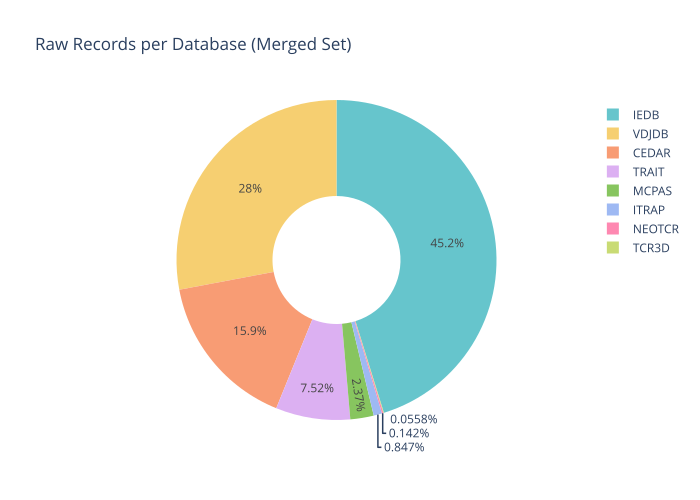

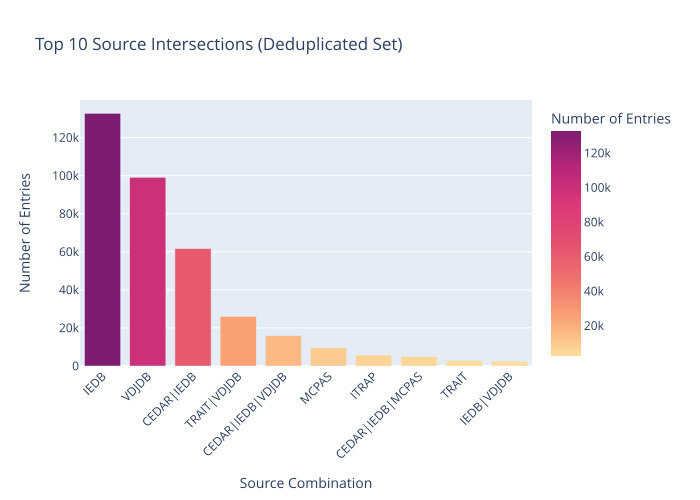

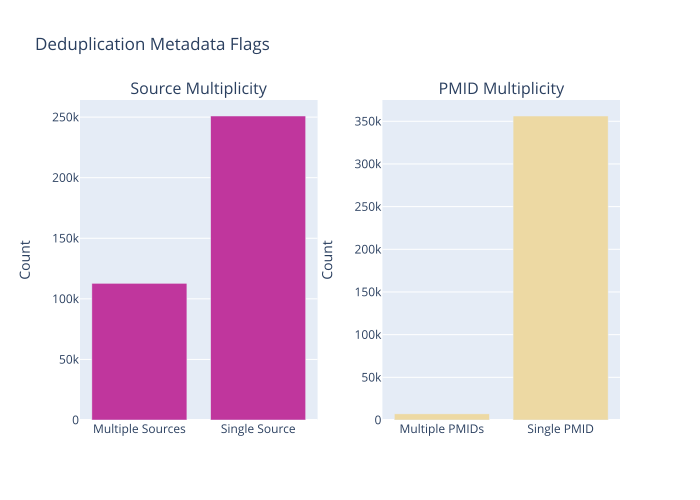

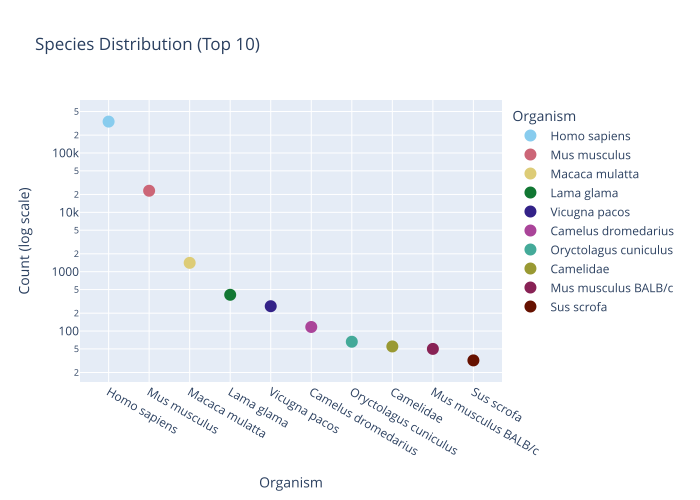

In [3]:
from plotly.subplots import make_subplots

# 1. Merged Data Distribution (Before Deduplication)
merged_source_counts = adata_merged.obs['source'].value_counts().reset_index()
merged_source_counts.columns = ['Source', 'Raw Count']

fig_merged = px.pie(merged_source_counts, names='Source', values='Raw Count', 
                  title="Raw Records per Database (Merged Set)",
                  hole=0.4, color_discrete_sequence=px.colors.qualitative.Pastel)
fig_merged.show()

# 2. Overlap Analysis (Deduplicated Data)
# Each entry can have multiple sources separated by '|'
sources_list = adata_dedup.obs['source'].str.split('|')

intersection_counts = (
     adata_dedup.obs['source'].value_counts()
    .head(10)
    .rename_axis('intersection_name')
    .reset_index(name='count')
    .sort_values('count', ascending=False)
 )

fig_overlap = px.bar(intersection_counts, x='intersection_name', y='count',
                   title="Top 10 Source Intersections (Deduplicated Set)",
                   labels={'intersection_name': 'Source Combination', 'count': 'Number of Entries'},
                   color='count', color_continuous_scale='Sunsetdark')
fig_overlap.update_layout(xaxis_tickangle=-45)
fig_overlap.show()

# Metadata for Multi-Source/PMID Analysis (split into side-by-side subplots)
source_metrics = pd.DataFrame({
    'Metric': ['Multiple Sources', 'Single Source'],
    'Count': [
        adata_dedup.obs['source'].str.contains('|', regex=False).sum(),
        (~adata_dedup.obs['source'].str.contains('|', regex=False)).sum()
    ]
})

pmid_metrics = pd.DataFrame({
    'Metric': ['Multiple PMIDs', 'Single PMID'],
    'Count': [
        adata_dedup.obs['PMID'].str.contains('|', regex=False).sum(),
        (~adata_dedup.obs['PMID'].str.contains('|', regex=False)).sum()
    ]
})

fig_meta = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Source Multiplicity', 'PMID Multiplicity'),
    horizontal_spacing=0.12
)

fig_meta.add_trace(
    go.Bar(
        x=source_metrics['Metric'],
        y=source_metrics['Count'],
        marker_color=px.colors.sequential.Agsunset[2],
        name='Source Metrics'
    ),
    row=1, col=1
)

fig_meta.add_trace(
    go.Bar(
        x=pmid_metrics['Metric'],
        y=pmid_metrics['Count'],
        marker_color=px.colors.sequential.Agsunset[6],
        name='PMID Metrics'
    ),
    row=1, col=2
)

fig_meta.update_layout(
    title_text='Deduplication Metadata Flags',
    showlegend=False
 )
fig_meta.update_yaxes(title_text='Count', row=1, col=1)
fig_meta.update_yaxes(title_text='Count', row=1, col=2)
fig_meta.show()

# 3. Species Distribution
species_df = adata_dedup.obs['source_organism'].value_counts().reset_index()
species_df.columns = ['Organism', 'Count']
# Show top 10 species only
species_df_top10 = species_df.head(10)
fig_spec = px.scatter(
    species_df_top10,
    x='Organism',
    y='Count',
    color='Organism',
    title="Species Distribution (Top 10)",
    color_discrete_sequence=px.colors.qualitative.Safe
)
fig_spec.update_traces(mode='markers', marker=dict(size=12))
# Update layout to fix clipped legend at bottom and rotate labels
fig_spec.update_layout(
    margin=dict(b=100),
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=1.02
    )
)
fig_spec.update_yaxes(type='log', title_text='Count (log scale)')
fig_spec.show()

## MHC Context Availability
Availability of MHC class and gene information varies significantly by database origin.
We visualize the proportion of records containing MHC Class I or Class II information.

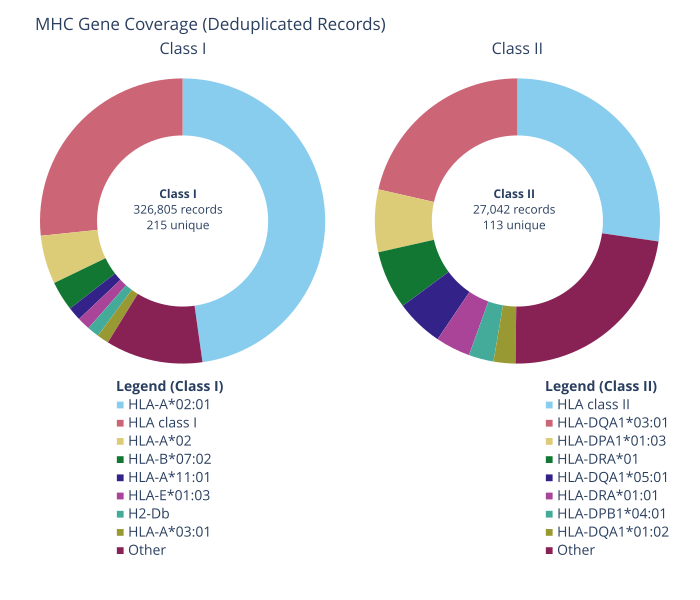

In [4]:
# Normalize MHC_class strings (handle None or nan)
def _clean_mhc_class(value):
    if pd.isna(value):
        return None
    text = str(value).strip()
    if text in {"", "None", "none", "nan", "NaN", "<NA>"}:
        return None
    if text == "I":
        return "Class I"
    if text == "II":
        return "Class II"
    if text in {"Class I", "Class II"}:
        return text
    return text

def _missing_mask(series):
    s = series.astype("string").str.strip()
    return s.isna() | s.isin(["", "None", "none", "nan", "NaN", "<NA>"])

def _top_gene_counts(series, top_n=8):
    counts = series.value_counts()
    if counts.empty:
        return pd.DataFrame({"MHC gene": ["No data"], "Count": [1]})
    top = counts.head(top_n)
    if len(counts) > top_n:
        top = pd.concat([top, pd.Series({"Other": counts.iloc[top_n:].sum()})])
    return top.reset_index().rename(columns={"index": "MHC gene", 0: "Count"})

def _legend_lines(labels, colors):
    return "<br>".join(
        f"<span style='color:{color}'>■</span> {label}"
        for label, color in zip(labels, colors)
    )

mhc_df = adata_dedup.obs[["MHC_class", "MHC_gene_1"]].copy()
mhc_df["MHC_class_clean"] = mhc_df["MHC_class"].apply(_clean_mhc_class)

class_i_df = mhc_df[mhc_df["MHC_class_clean"] == "Class I"]
class_ii_df = mhc_df[mhc_df["MHC_class_clean"] == "Class II"]

gene_i = class_i_df["MHC_gene_1"].astype("string")
gene_ii = class_ii_df["MHC_gene_1"].astype("string")

missing_i = int(_missing_mask(gene_i).sum())
missing_ii = int(_missing_mask(gene_ii).sum())
missing_class = int(mhc_df["MHC_class_clean"].isna().sum())

gene_i_clean = gene_i[~_missing_mask(gene_i)]
gene_ii_clean = gene_ii[~_missing_mask(gene_ii)]

total_i = int(class_i_df.shape[0])
total_ii = int(class_ii_df.shape[0])
unique_i = int(gene_i_clean.nunique())
unique_ii = int(gene_ii_clean.nunique())

display(HTML(
    f"<p><em>Missing MHC class (unknown I/II): {missing_class:,}. Missing MHC gene (MHC_gene_1): Class I = {missing_i:,}, Class II = {missing_ii:,}.</em></p>"
))

top_i = _top_gene_counts(gene_i_clean, top_n=8)
top_ii = _top_gene_counts(gene_ii_clean, top_n=8)

from plotly.subplots import make_subplots

palette = px.colors.qualitative.Safe
colors_i = [palette[i % len(palette)] for i in range(len(top_i))]
colors_ii = [palette[i % len(palette)] for i in range(len(top_ii))]

fig_mhc = make_subplots(
    rows=2, cols=2,
    specs=[[{"type": "domain"}, {"type": "domain"}], [{"type": "xy"}, {"type": "xy"}]],
    subplot_titles=("Class I", "Class II", "", ""),
    row_heights=[0.7, 0.3],
    vertical_spacing=0.08,
    horizontal_spacing=0.08
 )

fig_mhc.add_trace(
    go.Pie(
        labels=top_i["MHC gene"],
        values=top_i["Count"],
        hole=0.6,
        sort=False,
        textinfo="none",
        hovertemplate="%{label}: %{percent} (%{value})<extra></extra>",
        marker=dict(colors=colors_i),
        name="Class I"
    ),
    row=1, col=1
 )

fig_mhc.add_trace(
    go.Pie(
        labels=top_ii["MHC gene"],
        values=top_ii["Count"],
        hole=0.6,
        sort=False,
        textinfo="none",
        hovertemplate="%{label}: %{percent} (%{value})<extra></extra>",
        marker=dict(colors=colors_ii),
        name="Class II"
    ),
    row=1, col=2
 )

fig_mhc.update_layout(
    title_text="MHC Gene Coverage (Deduplicated Records)",
    showlegend=False,
    height=600,
    margin=dict(r=40, l=40, t=60, b=40)
 )

fig_mhc.add_annotation(
    text=f"<b>Class I</b><br>{total_i:,} records<br>{unique_i:,} unique",
    x=0.14, y=0.75,
    xref="paper", yref="paper",
    showarrow=False,
    align="center",
    font=dict(size=12)
 )

fig_mhc.add_annotation(
    text=f"<b>Class II</b><br>{total_ii:,} records<br>{unique_ii:,} unique",
    x=0.84, y=0.75,
    xref="paper", yref="paper",
    showarrow=False,
    align="center",
    font=dict(size=12)
 )

fig_mhc.add_annotation(
    text=f"<b>Legend (Class I)</b><br>{_legend_lines(top_i['MHC gene'], colors_i)}",
    x=0.12, y=0,
    xref="paper", yref="paper",
    showarrow=False,
    align="left",
    font=dict(size=14)
 )

fig_mhc.add_annotation(
    text=f"<b>Legend (Class II)</b><br>{_legend_lines(top_ii['MHC gene'], colors_ii)}",
    x=1.04, y=0,
    xref="paper", yref="paper",
    showarrow=False,
    align="left",
    font=dict(size=14)
 )

fig_mhc.update_xaxes(visible=False, row=2, col=1)
fig_mhc.update_yaxes(visible=False, row=2, col=1)
fig_mhc.update_xaxes(visible=False, row=2, col=2)
fig_mhc.update_yaxes(visible=False, row=2, col=2)

fig_mhc.show()


In [5]:
print("Source counts for 'HLA class I' entries:")
adata_dedup.obs[adata_dedup.obs["MHC_gene_1"]=="HLA class I"]["source"].value_counts().head(2)

Source counts for 'HLA class I' entries:


source
IEDB          87078
CEDAR|IEDB       35
Name: count, dtype: int64

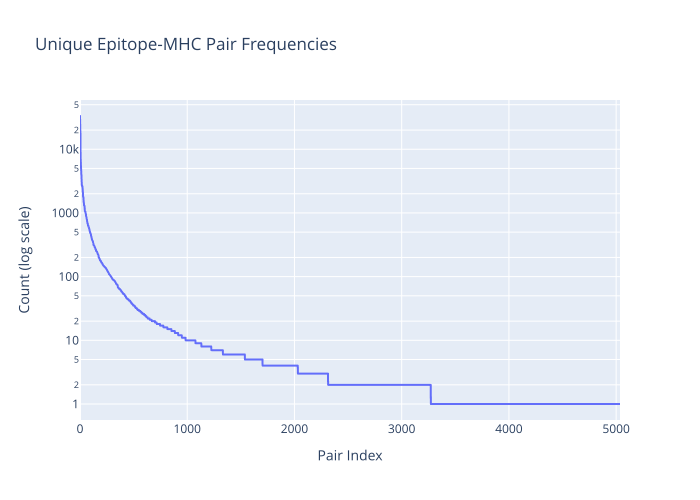

In [6]:
# Unique epitope (peptide) - MHC pair distributions
pair_df = adata_dedup.obs[["epitope_sequence", "MHC_gene_1"]].copy()
pair_df = pair_df.dropna(subset=["epitope_sequence", "MHC_gene_1"])

# create a single concatenated key and count
pair_df["pair"] = pair_df["epitope_sequence"].astype(str) + " || " + pair_df["MHC_gene_1"].astype(str)
pair_counts = pair_df["pair"].value_counts().reset_index()
pair_counts.columns = ["pair", "Frequency"]


fig_pairs = px.line(
    pair_counts.reset_index(drop=True),
    x=pair_counts.reset_index()['index'],
    y='Frequency',
    title='Unique Epitope-MHC Pair Frequencies',
    labels={'x': 'Pair Index', 'Frequency': 'Count'}
)
fig_pairs.update_yaxes(type='log', title_text='Count (log scale)')
fig_pairs.update_xaxes(title_text='Pair Index')
fig_pairs.show()



## TCR Chain Configuration (QC)
Using the `scirpy.tl.chain_qc` tool, we categorize the structural quality of the receptors. A high proportion of "Productive" pairs (Alpha+Beta) indicates better biological quality for structural modeling.

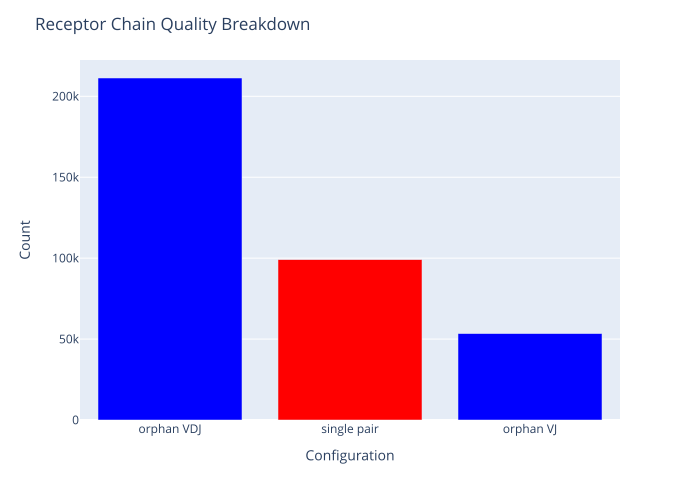

In [7]:
# Run QC
ir.tl.chain_qc(adata_dedup, inplace=True)
qc_df = adata_dedup.obs['chain_pairing'].value_counts().reset_index()
qc_df.columns = ['Configuration', 'Count']

fig_qc = px.bar(qc_df, x='Configuration', y='Count', color='Configuration', color_discrete_sequence=px.colors.sequential.Bluered)
fig_qc.update_layout(title_text="Receptor Chain Quality Breakdown", showlegend=False)
fig_qc.show()

## Sequence Distributions and Coverage
CDR3 (junction_aa) and Epitope lengths for biological consistency validation. 
Consistent distributions across sources suggest cross-database compatibility.

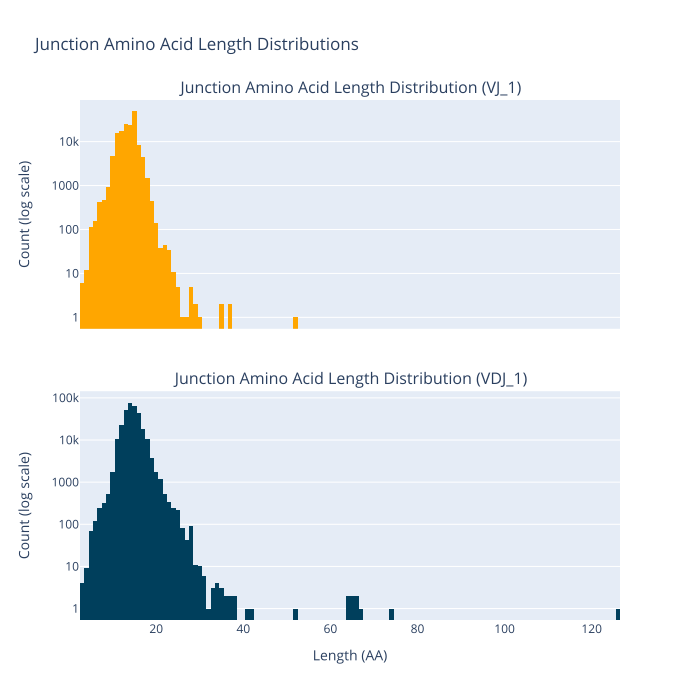

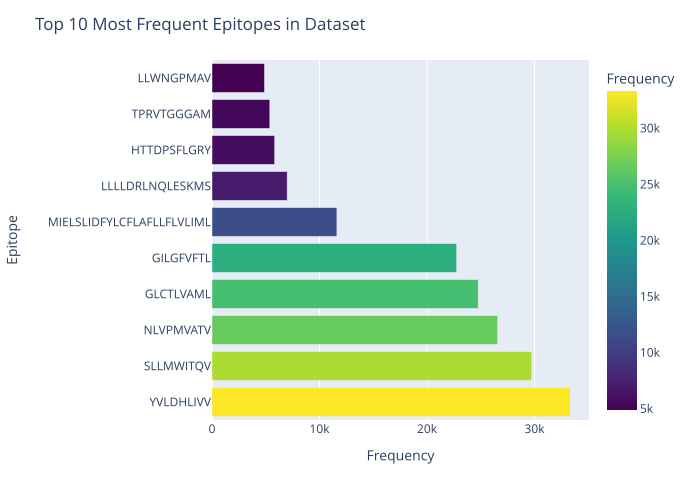

In [8]:
from plotly.subplots import make_subplots

with ir.get.airr_context(adata_dedup, ["junction_aa"], chain=["VJ_1", "VDJ_1"]) as m:
    df_len = m.obs.copy()
    # Calculate lengths while ignoring NaN/None
    df_len['VJ_len'] = df_len['VJ_1_junction_aa'].apply(lambda x: len(str(x)) if pd.notna(x) and x != 'None' else np.nan)
    df_len['VDJ_len'] = df_len['VDJ_1_junction_aa'].apply(lambda x: len(str(x)) if pd.notna(x) and x != 'None' else np.nan)

# One figure with two stacked histograms
fig_len = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.12,
    subplot_titles=(
        "Junction Amino Acid Length Distribution (VJ_1)",
        "Junction Amino Acid Length Distribution (VDJ_1)"
    )
)

fig_len.add_trace(
    go.Histogram(x=df_len["VJ_len"], marker_color="#ffa600", name="VJ_1 Chain"),
    row=1, col=1
)

fig_len.add_trace(
    go.Histogram(x=df_len["VDJ_len"], marker_color="#003f5c", name="VDJ_1 Chain"),
    row=2, col=1
)

fig_len.update_xaxes(title_text="Length (AA)", row=2, col=1)
fig_len.update_yaxes(title_text="Count (log scale)", type="log", row=1, col=1)
fig_len.update_yaxes(title_text="Count (log scale)", type="log", row=2, col=1)

fig_len.update_layout(
    title_text="Junction Amino Acid Length Distributions",
    showlegend=False,
    height=700
)

fig_len.show()

# Top Epitopes
top_ept = adata_dedup.obs['epitope_sequence'].value_counts().head(10).reset_index()
top_ept.columns = ['Epitope', 'Frequency']
fig_ept = px.bar(top_ept, x='Frequency', y='Epitope', orientation='h', color='Frequency', color_continuous_scale='Viridis')
fig_ept.update_layout(title_text="Top 10 Most Frequent Epitopes in Dataset")
fig_ept.show()

### Junction Sequence Logos by Receptor Type
Because junction_aa sequences vary in length, logos are computed on fixed windows of 8 amino acids from the left (start) and from the right (end).
For each receptor class (TCR, BCR), we show four logos side by side in a 2x2 layout: VJ-left, VJ-right, VDJ-left, and VDJ-right.

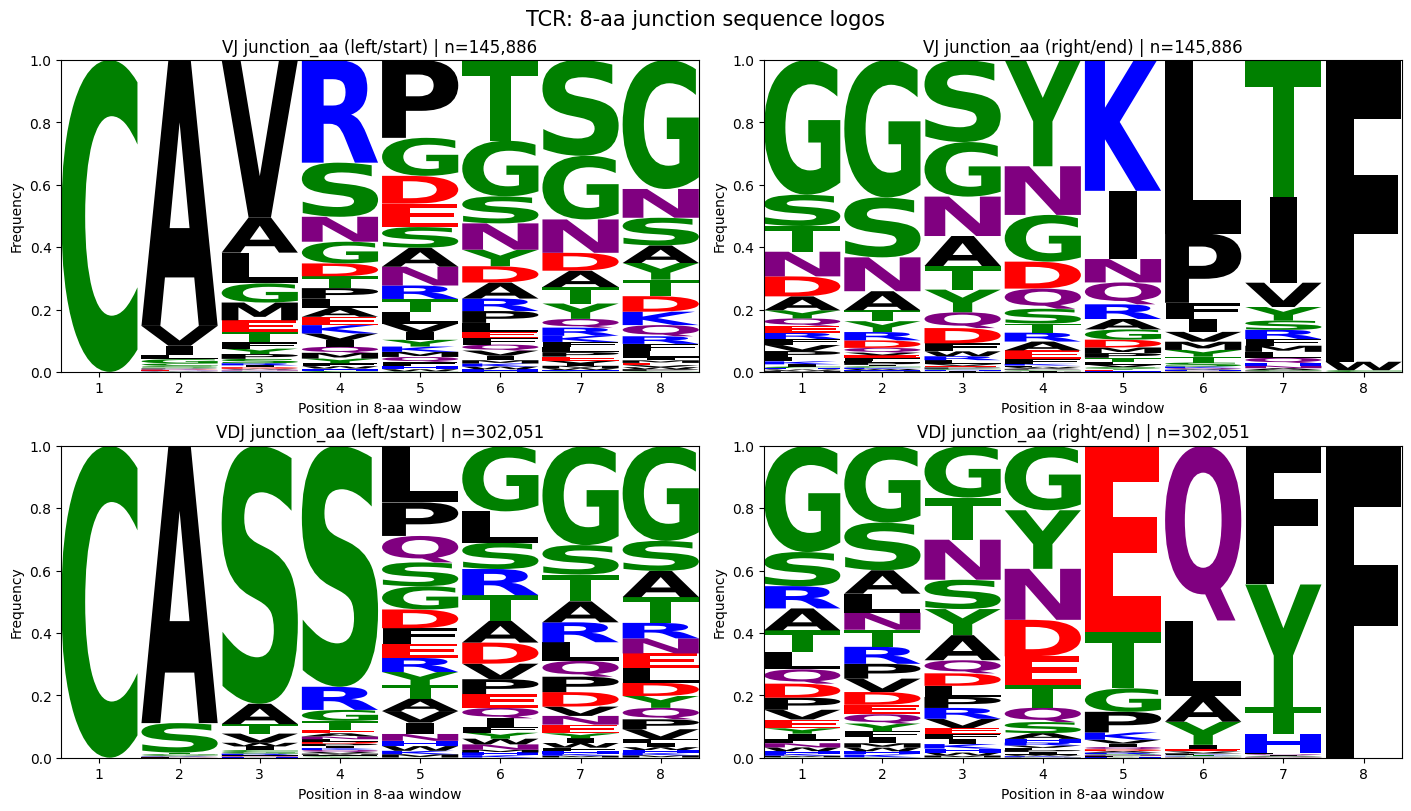

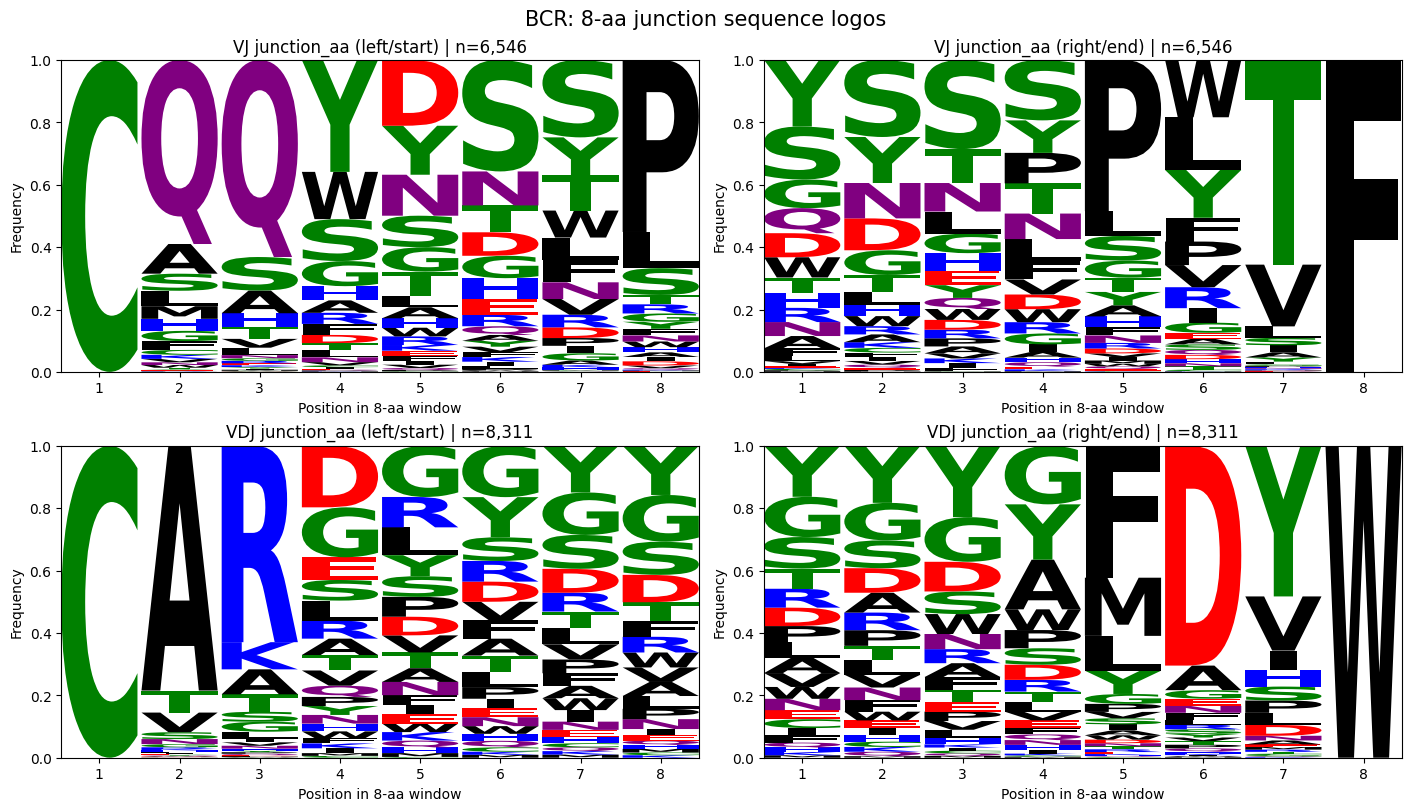

In [9]:
import matplotlib.pyplot as plt
import logomaker

WINDOW = 8

with ir.get.airr_context(adata_dedup, ['junction_aa', 'locus'], chain=['VJ_1', 'VDJ_1']) as m:
    df_logo = m.obs.copy()

tcr_vj_loci = {'TRA', 'TRG'}
tcr_vdj_loci = {'TRB', 'TRD'}
bcr_vj_loci = {'IGK', 'IGL'}
bcr_vdj_loci = {'IGH'}

mask_tcr = df_logo['VJ_1_locus'].isin(tcr_vj_loci) | df_logo['VDJ_1_locus'].isin(tcr_vdj_loci)
mask_bcr = df_logo['VJ_1_locus'].isin(bcr_vj_loci) | df_logo['VDJ_1_locus'].isin(bcr_vdj_loci)

def _clean_seq(x):
    if pd.isna(x):
        return None
    s = str(x).strip().upper()
    if s in {'', 'NONE', 'NAN'}:
        return None
    return s

def extract_window_sequences(series, side='left', window=8):
    seqs = []
    for x in series:
        s = _clean_seq(x)
        if s is None:
            continue
        if side == 'left':
            w = s[:window].ljust(window, '-')
        else:
            w = s[-window:].rjust(window, '-')
        seqs.append(w)
    return seqs

def plot_logo(ax, sequences, title):
    if len(sequences) == 0:
        ax.text(0.5, 0.5, 'No sequences available', ha='center', va='center', fontsize=11)
        ax.set_axis_off()
        return

    count_matrix = logomaker.alignment_to_matrix(
        sequences=sequences,
        to_type='counts',
        characters_to_ignore='-'
    )

    probs = count_matrix.div(count_matrix.sum(axis=1).replace(0, np.nan), axis=0).fillna(0.0)
    logomaker.Logo(probs, ax=ax, color_scheme='chemistry')

    ax.set_title(title)
    ax.set_ylabel('Frequency')
    ax.set_xlabel('Position in 8-aa window')
    ax.set_ylim(0, 1.0)
    ax.set_xticks(range(WINDOW))
    ax.set_xticklabels([str(i + 1) for i in range(WINDOW)])

def plot_receptor_logo_panel(df_sub, receptor_name):
    fig, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True)
    configs = [
        ('VJ_1_junction_aa', 'left',  'VJ junction_aa (left/start)'),
        ('VJ_1_junction_aa', 'right', 'VJ junction_aa (right/end)'),
        ('VDJ_1_junction_aa', 'left',  'VDJ junction_aa (left/start)'),
        ('VDJ_1_junction_aa', 'right', 'VDJ junction_aa (right/end)'),
    ]

    for ax, (col, side, label) in zip(axes.flat, configs):
        seqs = extract_window_sequences(df_sub[col], side=side, window=WINDOW)
        plot_logo(ax, seqs, f"{label} | n={len(seqs):,}")

    fig.suptitle(f"{receptor_name}: 8-aa junction sequence logos", fontsize=15)
    plt.show()

plot_receptor_logo_panel(df_logo.loc[mask_tcr], 'TCR')
plot_receptor_logo_panel(df_logo.loc[mask_bcr], 'BCR')

In [10]:
# ## V/J Gene Presence and Complete-Receptor Coverage

with ir.get.airr_context(adata_dedup, ["v_call", "j_call", "junction_aa"], chain=["VJ_1", "VDJ_1"]) as m:
    df_gene = m.obs[
        [
            "VJ_1_v_call", "VJ_1_j_call", "VJ_1_junction_aa",
            "VDJ_1_v_call", "VDJ_1_j_call", "VDJ_1_junction_aa",
        ]
    ].copy()

def _is_present(series):
    s = series.astype("string").str.strip()
    return s.notna() & ~s.isin(["", "None", "none", "nan", "NaN", "<NA>"])

presence_mask = {col: _is_present(df_gene[col]) for col in df_gene.columns}

# Unique gene counts observed (non-null) per chain/gene type
unique_gene_counts = pd.DataFrame(
    [
        {
            "Chain": "VJ_1",
            "Gene": "V",
            "Unique genes": int(df_gene.loc[presence_mask["VJ_1_v_call"], "VJ_1_v_call"].astype(str).nunique()),
            "Records": int(presence_mask["VJ_1_v_call"].sum())
        },
        {
            "Chain": "VJ_1",
            "Gene": "J",
            "Unique genes": int(df_gene.loc[presence_mask["VJ_1_j_call"], "VJ_1_j_call"].astype(str).nunique()),
            "Records": int(presence_mask["VJ_1_j_call"].sum())
        },
        {
            "Chain": "VDJ_1",
            "Gene": "V",
            "Unique genes": int(df_gene.loc[presence_mask["VDJ_1_v_call"], "VDJ_1_v_call"].astype(str).nunique()),
            "Records": int(presence_mask["VDJ_1_v_call"].sum())
        },
        {
            "Chain": "VDJ_1",
            "Gene": "J",
            "Unique genes": int(df_gene.loc[presence_mask["VDJ_1_j_call"], "VDJ_1_j_call"].astype(str).nunique()),
            "Records": int(presence_mask["VDJ_1_j_call"].sum())
        },
    ]
)

# Records with complete V/J genes + CDR3 for both chains
complete_mask = (
    presence_mask["VJ_1_v_call"]
    & presence_mask["VJ_1_j_call"]
    & presence_mask["VJ_1_junction_aa"]
    & presence_mask["VDJ_1_v_call"]
    & presence_mask["VDJ_1_j_call"]
    & presence_mask["VDJ_1_junction_aa"]
)
n_complete_both_chains = int(complete_mask.sum())
pct_complete = 100 * n_complete_both_chains / adata_dedup.n_obs

display(HTML("<h2>V/J Gene Presence</h2>"))
display(unique_gene_counts.sort_values(["Chain", "Gene"]).reset_index(drop=True))

display(
    HTML(
        f"""
        <p><strong>Records with complete annotations for both chains</strong><br>
        (V gene + J gene + CDR3 amino-acid sequence for VJ_1 and VDJ_1):</p>
        <p style="font-size:18px;"><strong>{n_complete_both_chains:,}</strong> / {adata_dedup.n_obs:,}
        ({pct_complete:.2f}%)</p>
        """
    )
)

,Chain,Gene,Unique genes,Records
0,VDJ_1,J,121,296451
1,VDJ_1,V,825,305626
2,VJ_1,J,196,140785
3,VJ_1,V,753,150014
